In [43]:
# Run this cell.
from datascience import *
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Lab 2: Visualization and Simpson's Paradox

**Goals:**
- Load and inspect real admissions data  
- Compare overall and department-level admission rates by gender  
- Visualize Simpson’s Paradox  

**Dataset Source:** The [dataset](https://discovery.cs.illinois.edu/dataset/berkeley/) used in this notebook is a cleaned version of the original UC Berkeley 1973 graduate admissions data, processed by the University of Illinois at Urbana-Champaign.

References:
* Freedman, Pisani, and Purves. "Sex Bias in Graduate Admissions." Statistics (1978) Chapter 2.  pp. 17-20.
* Bickel, Hammel, and O’Connell. "Sex Bias in Graduate Admissions: Data from Berkeley" Science vol. 187 (1975) pp. 398-404. [DOI](https://www.science.org/doi/10.1126/science.187.4175.398)
* [Wikipedia](https://en.wikipedia.org/wiki/Simpson%27s_paradox)

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## [Discussion] Data Talk

<div class="alert alert-info">

1. **What do you notice?**

2. **What do you wonder?**

3. **What story does this tell, especially about the community this data may impact?**

</div>

| Group   | Applicants | Admitted | Men Applicants | Men Admitted                                | Women Applicants | Women Admitted |
|---------|------------|----------|----------------|----------------------------------------------|------------------|----------------|
| **Total** | 12,763 | 41%   | 8,442       | <span style="color:green"><b>44%</b></span> | 4,321         | **35%**          |

| Dept | All Applicants | All Admitted | Men Applicants | Men Admitted | Women Applicants | Women Admitted |
|------|----------------|--------------|----------------|--------------|------------------|----------------|
| A    | 1,246            | 73%          | <span style="color:blue"><b>**1,138**</b></span> | 72%          | 108              | <span style="color:green"><b>82%</b></span> |
| B    | 585            | 63%          | <span style="color:blue"><b>**560**</b></span> | 63%          | 25               | <span style="color:green"><b>68%</b></span> |
| C    | 918            | 35%          | 325            | <span style="color:green"><b>37%</b></span> | <span style="color:blue"><b>**593**</b></span> | 34% |
| D    | 792            | 34%          | <span style="color:blue"><b>417</b></span> | 33%          | 375              | <span style="color:green"><b>35%</b></span> |
| E    | 584            | 25%          | 191            | <span style="color:green"><b>28%</b></span> | <span style="color:blue"><b>**393**</b></span> | 24% |
| F    | 714            | 7%           | <span style="color:blue"><b>373</b></span> | 6%           | 341              | <span style="color:green"><b>7%</b></span> |
| **Total** | **4,839**      | **43%**       | **3,004**      | <span style="color:green"><b>**50%**</b></span> | **1,835**        | **30%**        |

<hr style="border: 1px solid #fdb515;" />

### [Discussion] Visualization Talk

<img src="images/visualize_rates.png" alt="Total Rate bar chart and Admit Rate by Department" width="100%"/>

<div class="alert alert-info">

1. **What do you notice?**

2. **What do you wonder?**

3. **What columns plotted what?** (Focus on axes)

</div>

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Introduction to Jupyter Notebooks

### [Tutorial] Python the Calculator

The two building blocks of Python code are *expressions* and *statements*.  An **expression** is a piece of code that

* is self-contained, meaning it would make sense to write it on a line by itself, and
* usually evaluates to a value.

The below expression evaluates to 3:

In [2]:
# just run this cell
5 - 2

3

One important type of expression is the **call expression**. A call expression begins with the name of a function and is followed by the argument(s) of that function in parentheses. The function returns some value, based on its arguments. For example the function `abs` returns the absolute value of its argument. The below call expression therefore also evaluates to 3:

In [3]:
# just run this cell
abs(2 - 5)

3



A **statement** is a whole line of code.  Some statements are just expressions, like the ones above.

Other statements *make something happen* rather than *having a value*. For example, an **assignment statement** assigns a value to a name. 

A good way to think about this is that we're **evaluating the right-hand side** of the equals sign and **assigning it to the left-hand side**. Here are some assignment statements:
    
```
height = 1.3
the_number_five = abs(-5)
absolute_height_difference = abs(height - 1.688)
```

An important idea in programming is that large, interesting things can be built by combining many simple, uninteresting things.  The key to understanding a complicated piece of code is breaking it down into its simple components.

In [4]:
# if you'd like, copy the lines above into this cell
# and try running it.

## Part 1: Table Transformations

### [Tutorial] Load the data

Load in the file below by running the cell below. 

<div class="alert alert-info">

How is this data different from the tables you analyzed above? How might we build the table above from the one below?

</div>

In [5]:
# just run this cell
cal_data = Table.read_table('UCBerkeley1973_Admission.csv')
cal_data.show(5)

Year,Major,Gender,Admission
1973,C,F,Rejected
1973,B,M,Admitted
1973,Other,F,Admitted
1973,Other,M,Admitted
1973,Other,M,Rejected


We can **transform** this table in many ways by performing an operation on its rows. Let's say we wanted all the applicants who were admitted. We can use the table method `where`:

In [6]:
# just run this cell
cal_data.where("Admission", "Admitted")

Year,Major,Gender,Admission
1973,B,M,Admitted
1973,Other,F,Admitted
1973,Other,M,Admitted
1973,F,F,Admitted
1973,Other,M,Admitted
1973,A,M,Admitted
1973,B,M,Admitted
1973,A,M,Admitted
1973,Other,F,Admitted
1973,C,M,Admitted


### [Tutorial] `where` and `num_rows`

Now let's dive into the details a bit more. `where` takes 2 arguments:

1. The name of a column.  `where` finds rows where that column's values meet some criterion.
2. A predicate that describes the criterion that the column needs to meet.

The expression above found all rows whose `"Admission"` value matched `"Admitted"`. `where` returns a table that's a copy of the original table, but **with only the rows that meet the given predicate**.

To **count** the number of rows in a table, we can use `num_rows`. The table property `num_rows` returns the number of rows in a table. (A "property" is just a method that doesn't need to be called by adding parentheses.)

_Note_: The terms "method" and "function" are technically not the same thing, but for the purposes of this course, we will use them interchangeably.

The expression below does many things. Try talking it through with a neighbor, then expand the explanation below.

<details>
    <summary>Explanation</summary>

* Below, the "equals" sign (`=`) assigns the left-hand side name to the value of the right-hand side.
* The right-hand side:
  * `where` returns a table that's a copy of the original table, but only contains rows where the column matches a value, e.g., `"Gender"` matches `"F"`.
  * `num_rows` gets the numbers of rows that match the `where`.
* `print` is a special function. The `print` expression displays the values we care about.

</details>

In [7]:
# just run this cell
total_f = cal_data.where("Gender", "F").num_rows
print(total_f)

4321


Test your understanding! What do you think the "double" `where` does below?

<details>
    <summary>Explanation</summary>

Since the value of the expression `cal_data.where("Admission", "Admitted")` is itself a table, you can just call a table method on it.

</details>

In [8]:
# just run this cell
total_f = cal_data.where("Gender", "F").num_rows
total_m = cal_data.where("Gender", "M").num_rows
admit_f = cal_data.where("Admission", "Admitted").where("Gender", "F").num_rows #number of female applicants who were accepted
admit_m =  cal_data.where("Admission", "Admitted").where("Gender", "M").num_rows #number of male applicants who were accepted

print(total_f, "total number of female applicants")
print(total_m, "total number of male applicants")
print(admit_f, "number of female applicants admitted")
print(admit_m, "number of male applicants admitted")

4321 total number of female applicants
8442 total number of male applicants
1494 number of female applicants admitted
3738 number of male applicants admitted


Now that we've built these values, we can use them in mathematical expressions.

In [9]:
# just run this cell
print(cal_data.num_rows, "number of rows in table")

total = total_f + total_m
print(total, "number of applicants")

12763 number of rows in table
12763 number of applicants


### Question 1: Compute Admit Rate

Fill in the `...` with the given named values

* `total_f`
* `total_m`
* `admit_f`, and
* `admit_m`

to compute the 1973 admission rates (admit rates, in %) for

* women (`admit_rate_f`) and
* men (`admit_rate_m`).

**NOTE:** In Python, `/` is division, and `*` is multiplication. How might we compute percentages (between 0 and 100)?

**Note 2**: If you are encountering an error, raise your hand and we will come by to help.

In [10]:
# TODO: replace the "..." below!
admit_rate_f = admit_f / total_f * 100 # SOLUTION
admit_rate_m = admit_m / total_m * 100 # SOLUTION

# do not edit below this line
print("1973's Berkeley admission rate:")
print("female:", admit_rate_f, "%")
print("male:", admit_rate_m, "%")

1973's Berkeley admission rate:
female: 34.57532978477204 %
male: 44.27860696517413 %


### [Tutorial] Run the autograder for Question 1

This notebook is built with a Python autograder package called Otter Grader. For certain coding cells, we provide an autograder `grader` cell that checks the values and variables computed thus far in the notebook.

As an example, once you are satisfied with your work above, run the below cell to check your answer with the autograder. If you encounter an error, double-check your work, and also double-check that you have run the first cell of this notebook.

In [11]:
import numpy as np
assert np.isclose(admit_rate_f, 34.57532978477204)


In [12]:
assert np.isclose(admit_rate_m, 44.27860696517413)


### [Tutorial] `.pivot` (Berkeley admissions)

Let's practice one classical table transformation. The `pivot` method creates a two-way table showing the intersection of two columns.

`pivot(columns, rows, values=None, collect=None)`

- `columns`: unique values become the new column headers
- `rows`: unique values become the row labels
- if you do **not** pass `values` and `collect`, each cell is a **count of rows**

*Example*: For this dataset,

- `columns='Admission'` gives columns like `Admitted` and `Rejected`
- `rows='Gender'` gives rows for `F` and `M`

So running the below cell builds a table `admit_vs_reject` that answers:

> For each gender, how many applications were admitted vs. rejected?

In [13]:
# just run this cell
admit_vs_reject = cal_data.pivot('Admission', 'Gender')
admit_vs_reject

Gender,Admitted,Rejected
F,1494,2827
M,3738,4704


### Question 2: Build `count_by_dept`

Using the `cal_data` table loaded earlier and the table method from the section above, complete the cell below to create a table named `count_by_dept` that shows the **number** (count) of applicants by **Major and Gender**. Your `count_by_dept` table should look like the following:

| Major | F | M |
| :-- | :-- | :-- |
| A	| 108 |	1138 |
| B	| 25 | 560 |
| C | 593 | 325 |
| D | 375 | 417 |
| E | 393 | 191 |
| F | 341 | 373 |
| Other | 2486 | 5438 |

**IMPORTANT NOTE:** 
Use the correct column names as strings. The string of the column names that you want to pass into as the arguments must have the exact match in capitalization, spelling, spaces, etc.

In [14]:
count_by_dept = cal_data.pivot('Gender', 'Major') #SOLUTION
count_by_dept

Major,F,M
A,108,1138
B,25,560
C,593,325
D,375,417
E,393,191
F,341,373
Other,2486,5438


In [15]:
assert list(count_by_dept.labels) == ['Major', 'F', 'M']

In [16]:
assert "F" in count_by_dept.column("Major")

In [17]:
assert count_by_dept.where("Major", "A").column("F").item(0) == 108

In [18]:
assert count_by_dept.where("Major", "A").column("M").item(0) == 1138

### Question 3: Build `admit_by_dept`

Recall what we said earlier:

> Since the value of the expression `cal_data.where("Admission", "Admitted")` is itself a table, you can just call a table method on it.

Now, we know a second table method: `pivot`...!

Put together what you know about `where` and `pivot` to use `cal_data` to build the `admit_by_dept` table that shows the **number** (count) of **admits** by major and gender. Your `admit_by_dept` table should look like the following:

| Major | F | M |
| :-- | :-- | :-- |
| A	| 89 |	825 |
| B |	17 |	353 |
| C |	201 |	120 |
| D	 | 131 |	138 |
| E	| 94 |	53 |
| F |	25 |	22 |
| Other |	937 |	2227 |

In [19]:
admit_by_dept = cal_data.where("Admission", "Admitted").pivot('Gender', 'Major') #SOLUTION
admit_by_dept

Major,F,M
A,89,825
B,17,353
C,201,120
D,131,138
E,94,53
F,25,22
Other,937,2227


In [20]:
assert list(admit_by_dept.labels) == ['Major', 'F', 'M']

In [21]:
assert "F" in admit_by_dept.column("Major")

In [22]:
assert admit_by_dept.where("Major", "A").column("F").item(0) == 89

In [23]:
assert admit_by_dept.where("Major", "A").column("M").item(0) == 825

We will reuse your newly created `count_by_dept` and `admit_by_dept` tables later in Part 3's visualizations with bar charts. For now, you are done with this section, so give yourself a pat on the back!

For those curious, check our the full list of [table transformations](https://data6.org/notes/reference#tables-and-table-methods) available in the `datascience` package.

We'll circle back for some discussion before we revisit the next part.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part 3: Bar Charts

The "proper pooling" section of the [Simpson's paradox visualization](https://setosa.io/simpsons/) encodes **four** variables:

a. Total admits (and rejects) by gender
b. Admits (and rejects) by department
c. Total admit rate by gender
d. Admit rate by department

These can all be visualized with bar charts (one per variable). Let's tackle (a) and (c) first.

### [Tutorial]`.barh` (Berkeley admissions)

Use `.barh` to make a **horizontal bar chart** or `.bar` to make a **vertical bar chart** from a table with categories.

(horizontal) `table.barh(category_column, optional_numeric_columns)` <br/>
(vertical) `table.bar(category_column, optional_numeric_columns)` 

- first argument: the category labels (y-axis)
- if no numeric columns are specified, `barh` plots all numeric columns

### (a) [Tutorial] Plot Total Admits by Gender

Earlier, we built the `admit_vs_reject` table for you:

In [24]:
# just run this cell
admit_vs_reject

Gender,Admitted,Rejected
F,1494,2827
M,3738,4704


We can use the `admit_vs_reject` table to plot a (horizontal) bar chart with one horizontal bar for each gender, disaggregated by accepted vs rejected counts.

* category column: `Gender`
* numeric columns: `Admitted`, `Rejected`

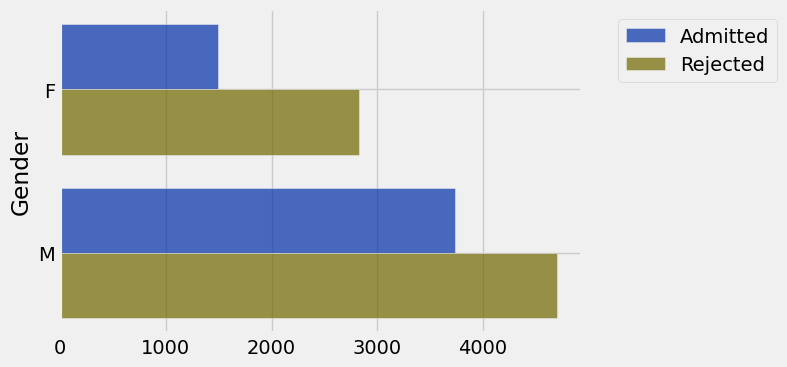

In [25]:
# just run this cell
admit_vs_reject.barh("Gender")

<hr style="border: 1px solid #fdb515;" />

### (b) Question 4: Plot Acceptance Counts by Department

Earlier, you built the `admit_by_dept` table:

In [26]:
# just run this cell
admit_by_dept

Major,F,M
A,89,825
B,17,353
C,201,120
D,131,138
E,94,53
F,25,22
Other,937,2227


Use the `admit_by_dept` table to plot the below bar chart.

<img src="images/admit_by_dept_count.png" alt="Bar Chart: Admit by Department (count)" width="60%"/>

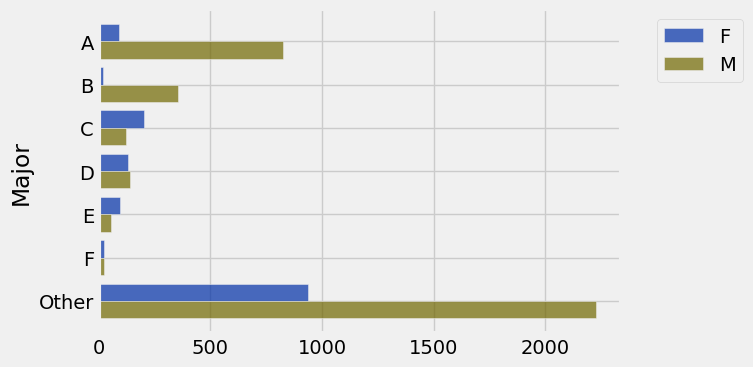

In [27]:
# TODO: write a line below, replacing the ...

admit_by_dept.barh("Major") # SOLUTION

### [Tutorial] Arrays and Tables

How can we add columns to tables? In the `datascience` library, we can make new columns by creating an **array**, which is a list of values, in order. Run the cell below and notice that `admit_rate` is an array with two elements.

In [28]:
admit_rate = make_array(admit_rate_f, admit_rate_m)
admit_rate

array([ 34.57532978,  44.27860697])

An array is **not** a table, because it doesn't have labeled columns.

We can add new columns to tables by calling `with_columns` on that table. The `with_columns` method requires two arguments:

1. The name of the first column as a string
1. An array of values to put in the first column
1. (optional) The name of the second column as a string
1. (optional) An array of values to put in the second column
1. (optional) etc.

For example, the `admit_vs_reject_rate` table below adds one column to `admit_vs_reject`; this column is labeled `"Admit Rate"` and has the values in the `admit_rate` array.

In [29]:
# just run this cell
admit_vs_reject_rate = admit_vs_reject.with_columns("Admit Rate", admit_rate)
admit_vs_reject_rate

Gender,Admitted,Rejected,Admit Rate
F,1494,2827,34.5753
M,3738,4704,44.2786


### (c) [Tutorial] Plot Acceptance Rates by Gender

We can then use our newly created `admit_vs_reject_rate` to plot a bar chart of the total admit **rates**, not the counts as before.

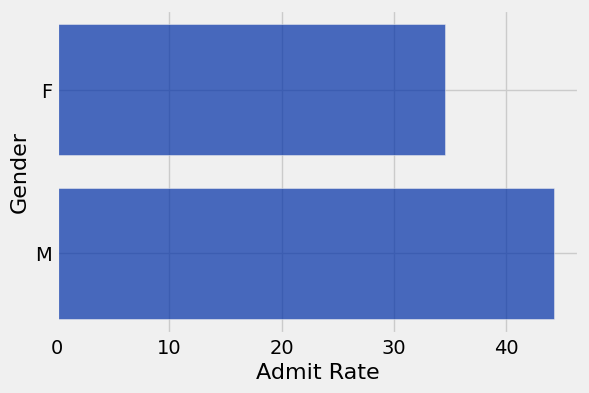

In [30]:
# just run this cell
admit_vs_reject_rate.barh("Gender", "Admit Rate")

### [Tutorial] Array Arithmetic

Now we are going to do something *really* cool: **array arithmetic.** This is when we use arrays themselves in expressions. When we do so, arithmetic is applied to each element individually.

The cell below illustrates how to use arrays to convert multiple temperatures in Celsius (in the `highs` array) to Farenheit:

<img src="images/temperatures.png" alt="Array Arithmetic visual of highs conversion Celsius to Farenheit" width="100%"/>

In [31]:
# just run this cell
highs = make_array(13.6, 14.387, 14.585, 15.164)

In [32]:
# just run this cell
(9/5) * highs + 32

array([ 56.48  ,  57.8966,  58.253 ,  59.2952])

Below, `Table()` returns an "empty" table, from which we can add new columns, provided that the number of elements in each column are equal.

In [33]:
# just run this cell. notice the new table...!
Table().with_columns("Celsius", highs,
                     "Farenheit", (9/5) * highs + 32)

Celsius,Farenheit
13.6,56.48
14.387,57.8966
14.585,58.253
15.164,59.2952


Above, we showed how to make columns out of arrays to add to existing tables or make new tables. But what about going the other way?

The `column` method takes a column label and returns a copy of the values of that column as an array (which, again, is a list of the values in that column, in order). For example, the below cell gets the "M" column in `count_by_dept` and stores it in `m_by_dept`:

In [34]:
# just run this cell
m_by_dept = count_by_dept.column("M")
m_by_dept

array([1138,  560,  325,  417,  191,  373, 5438])

Since the `column` method returns arrays, we can now perform array arithmetic "on columns." The below cell adds the number of male and female applicants by department and stores it in `total_by_dept`:

In [35]:
# just run this cell
total_by_dept = count_by_dept.column("M") + count_by_dept.column("F")
total_by_dept

array([1246,  585,  918,  792,  584,  714, 7924])

Before we introduce the next question, here is a refresher on two tables you have malready built:

In [36]:
# just run this cell
count_by_dept

Major,F,M
A,108,1138
B,25,560
C,593,325
D,375,417
E,393,191
F,341,373
Other,2486,5438


In [37]:
# just run this cell
admit_by_dept

Major,F,M
A,89,825
B,17,353
C,201,120
D,131,138
E,94,53
F,25,22
Other,937,2227


### Question 5: Compute Admit Rate by Department

Use the two tables `count_by_dept` and `admit_by_dept` with **the `column` method** to compute `admit_f_by_dept_rate` and `admit_m_by_dept_rate` to the admission **percentages** (between 0 and 100) of female and males to each department, respectively.

If all goes well, then running the cell below should correctly produce `admit_by_dept_rate`, a table of rates that match what you observed in the [Simpson's website demo](https://setosa.io/simpsons/).

In [38]:
# TODO: fill in the blanks
admit_f_by_dept_rate = admit_by_dept.column("F")/count_by_dept.column("F") * 100 # SOLUTION
admit_m_by_dept_rate = admit_by_dept.column("M")/count_by_dept.column("M") * 100 # SOLUTION

# do not edit below this line
admit_by_dept_rate = Table().with_columns(
                        "Major", admit_by_dept.column("Major"),
                        "F Admit Rate", admit_f_by_dept_rate,
                        "M Admit Rate", admit_m_by_dept_rate)
admit_by_dept_rate

Major,F Admit Rate,M Admit Rate
A,82.4074,72.4956
B,68,63.0357
C,33.8954,36.9231
D,34.9333,33.0935
E,23.9186,27.7487
F,7.33138,5.89812
Other,37.6911,40.9526


In [39]:
assert len(admit_f_by_dept_rate) == len(admit_m_by_dept_rate)

In [40]:
assert list(admit_by_dept_rate.labels) == ['Major', 'F Admit Rate', 'M Admit Rate']

In [41]:
assert admit_by_dept_rate.where("Major", "B").column("F Admit Rate").item(0) == 68

### (d) Question 6: Plot Admit Rate by Department


Finally, in the cell below, choose one of the many many tables that we have built over the entire notebook to plot the admit rate by department.

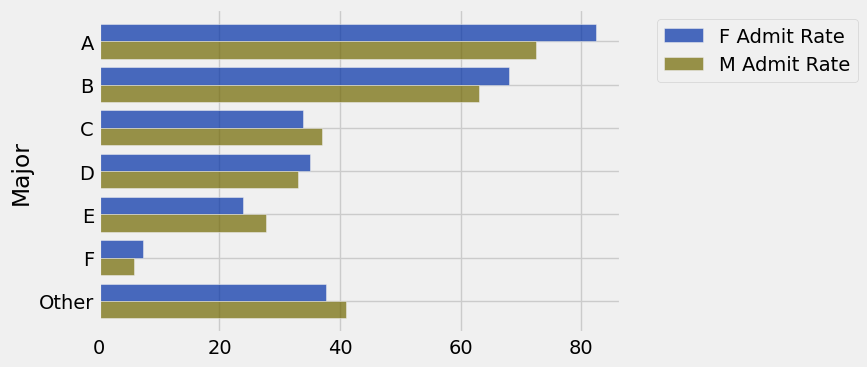

In [42]:
admit_by_dept_rate.barh("Major") # SOLUTION